device: cpu
length: 1026943
OLS  alpha=-0.1392  beta=0.5072
Spread  mean=0.0223  std=0.6919


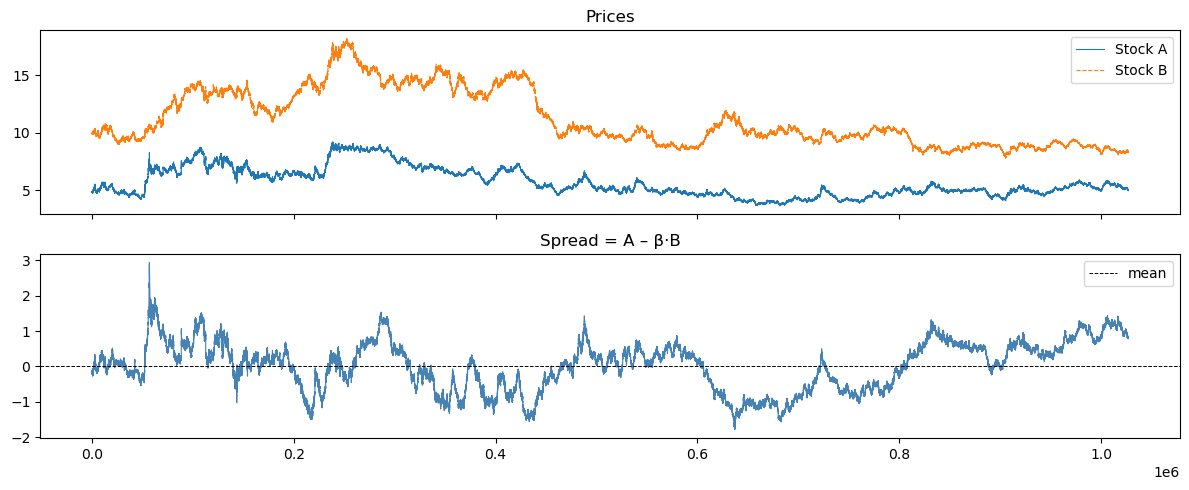

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
from collections import deque
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

# ── paste or import your env ──────────────────────────────────────────
# from pairs_trading_env import PairsTradingEnv
# If the file is in the same directory just uncomment the line above.
# Otherwise the full class is expected to be available as PairsTradingEnv.
# ─────────────────────────────────────────────────────────────────────
# 210 3 for 0.8 3,2 for 0.6 200x100 windows for 0.6 is very good; seed 11 for 400x100 for 0.5
SEED = 8
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

TRAIN_RATIO  = 0.80
# ── paths ─────────────────────────────────────────────────────────────
CSV_A = '../dataset/CORN_USD_2005_2020.csv'   # ← change to your file
CSV_B = '../dataset/WHEAT_USD_2005_2020.csv'   # ← change to your file
CSV_C = '../data-scripts/data_one_regime.csv'

CSV_D = '../dataset/WHEAT_USD_other_2005_2020.csv'
CSV_E = '../dataset/SOYBN_USD_other_2005_2020.csv'
# ─────────────────────────────────────────────────────────────────────

df_a = pd.read_csv(CSV_D).dropna()
df_b = pd.read_csv(CSV_E).dropna()

# df_a = pd.read_csv(CSV_C)[['s1']].dropna()
# df_b = pd.read_csv(CSV_C)[['s2']].dropna()
# df_a = df_a.rename(columns={"s1": "close"})
# df_b = df_b.rename(columns={"s2": "close"})

# import yfinance as yf
# df_a = yf.download("EOG", period="max", multi_level_index=False)[["Close"]].rename(columns={"Close": "close"})
# df_b = yf.download("XOM", period="max", multi_level_index=False)[["Close"]].rename(columns={"Close": "close"})
# start = max(df_a.index.min(), df_b.index.min())
# df_a, df_b = df_a.loc[start:], df_b.loc[start:]


# df_a = df_a[:int(0.5*len(df_a))]
# df_b = df_b[:int(0.5*len(df_b))]
n = len(df_a)
print(f"length: {n}")
# ── OLS: A = alpha + beta·B  →  beta = cov(A,B) / var(B) ────────────
A = df_a['close'].values
B = df_b['close'].values

split        = int(n * TRAIN_RATIO)
X = np.column_stack([np.ones(split), B[:split]])
beta_ols, _ = np.linalg.lstsq(X, A[:split], rcond=None)[0], None
alpha_ols = beta_ols[0]
beta      = beta_ols[1]
print(f'OLS  alpha={alpha_ols:.4f}  beta={beta:.4f}')

spread = A - beta * B
print(f'Spread  mean={spread.mean():.4f}  std={spread.std():.4f}')

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(A, label='Stock A', linewidth=0.8)
axes[0].plot(B, label=f'Stock B', linewidth=0.8, linestyle='--')
axes[0].legend(); axes[0].set_title('Prices')
axes[1].plot(spread, linewidth=0.8, color='steelblue')
axes[1].axhline(spread.mean(), color='k', linestyle='--', linewidth=0.7, label='mean')
axes[1].set_title('Spread = A – β·B'); axes[1].legend()
plt.tight_layout(); plt.show()